# 1.模型选择、欠拟合和过拟合
机器学习的目标是发现**模式**。我们真正的目的是要确定模型是真正发现了一种泛化的模式，而不是简单地记住数据。更正式地说，我们的目标是发现某些模式，这些模式捕获到了训练集潜在的总体规律。如果成功做到这点，即使是对以前从未遇到过的个体，模式也可以成功地评估风险。而这其中的困难在于，当我们训练模型时，只能访问数据集中的小部分样本。当我们使用有限的样本时，可能会遇到这样的问题：**当收集到更多的数据时，会发现之前找到的相关关系并不成立。**

将模型在训练数据上拟合的比在潜在分布中更接近的现象称为**过拟合**，用于对抗过拟合的技术就是**正则化**。

## 1.1 训练误差和泛化误差
$\cdot$ **训练误差：是指模型在训练数据集上计算得到的误差。** </br>
$\cdot$ **泛化误差：是指模型应用在同样从原始样本的分布中抽取的无限多数据样本时，模型误差的期望。** </br>
这里的问题是，我们永远不能准确地计算处泛化误差，这是因为无限多的数据样本是一个虚构的对象。在实际应用中，我们只能通过将模型应用于一个独立的测试集来估计泛化误差，该测试集由随机抽取的、未曾在训练集中出现的数据样本构成。

几个倾向于影响模型泛化的因素：</br>
$\cdot$ **可调整参数的数量。** 当可调整参数的数量很大时，模型往往更容易过拟合。 </br>
$\cdot$ **参数的取值。** 当权重的取值范围较大时，模型可能更容易过拟合。 </br>
$\cdot$ **训练样本的数量。** 即使模型很简单，也很容易拟合只包含一两个样本的数据集。而过拟合一个由数百万个样本的数据集则需要一及其灵活的模型。 </br>

## 1.2 模型选择
在机器学习中，我们通常在评估几个候选模型后选择最终的模型，这个过程叫作**模型选择**。**有时，需要比假的模型在本质上时完全不同的（比如，决策树与线性模型）。有时，我们需要比较不同超参数设置下的同一类模型。** </br>
例如，训练多层感知机模型时，我们可能希望比较具有不同数量的隐藏层、不同数量的隐藏单元以及不同数量的激活函数组合的模型。为了确定候选模型中的最佳模型，我们通常会使用验证集。
### 1. 验证集
原则上，在我们确定所有的超参数之前，我们不希望用到测试集。在模型选择的过程中，为了避免模型过拟合测试集，我们常将数据分成3份，除了训练集和测试集外再增加一个一个验证数据集，也称为**验证集**。
### 2. K折交叉验证
当训练数据稀缺时，我们甚至可能无法提供足够的数据来构成一个合适的验证集。这个问题的一个通常的解决方案是采用**K折交叉验证**。首先，原始训练数据被分成K个不重叠的子集；然后，执行K次模型训练和验证，每次在K-1个自己上进行训练，并在剩余的一个子集上进行验证；最后通过K次实验的结果取平均值来估计训练误差和验证误差。

## 1.3 欠拟合还是过拟合
当比较训练误差和验证误差时，我们要注意两种常见的情况。</br>
一种情况是，训练误差和验证误差都很大，但它们之间仅有一点差距。如果模型不能减小训练误差，可能意味着模型过于简单，无法捕获试图学习的模式。这种现象称为**欠拟合。**

另一种情况是，当我们的训练误差明显小于验证误差时，这表明**过拟合**。但是，过拟合并不总是一件坏事。并且最终，我们通常更关心验证误差，而不是训练误差和验证误差之间的差距。

时过拟合还是欠拟合可能取决于**模型的复杂性和可用训练数据集的大小。**

## 1.4 多项式回归
我们可以用多项式拟合来探索以上概念。

In [1]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l

### 1.生成数据集
给定x，我们将使用以下三阶多项式来生成训练数据和测试数据的标签：
$$
y = 5 + 1.2x - 3.4 \frac{x^2}{2!} + 5.6 \frac{x^3}{3!} + \epsilon
$$
$epsilon$服从均值为0且标准差为0.1的正态分布。在优化过程中，我们通常希望避免非常大的梯度值或损失值，这也就是为什么特征值从$x^i$调整为$\frac{x^i}{i!}$的原因。 

In [4]:
max_degree = 20 # 多项式的最大阶数
n_train, n_test = 100, 100 # 训练集和测试集的大小
true_w = np.zeros(max_degree) # 分配大量的空间，存储真实的权重系数
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6]) # 意味着真是模型实际只有4阶

features = np.random.normal(size = (n_train + n_test, 1)) # 生成200个服从标准正态分布(均值0，标准差1)的随机数作为特征x
np.random.shuffle(features)
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))
# np.arange(max_degree) 创建数组[0,1,2,...,19]
# 通过reshape(1, -1)将其变成行向量(1,20)
# np.power() 对features的每个值计算0到19次幂
# 结果poly_features的形状是(200, 20)

for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1) # gamma(n) = (n - 1) !
    # 每一列除以对应的阶乘，这是为了数值稳定性（泰勒展开的系数）
    
# labels的维度：(n_train+n_test,)
labels = np.dot(poly_features, true_w)
# 矩阵乘法：用多项式特征矩阵乘以真实权重
# 得到每个样本的真实标签值（没有噪声）

labels += np.random.normal(scale = 0.1, size = labels.shape)
# 添加高斯噪声，标准差为0.1

存储在poly_features中的单项式由gamma函数重新缩放，其中$\tau (n)$ = (n - 1)!

In [9]:
# numPyndarray转换为tensor
true_w, features, poly_features, labels = [torch.tensor( x, dtype = 
    torch.float32) for x in [true_w, features, poly_features, labels]]

In [11]:
features[:2], poly_features[:2, :], labels[:2]

(tensor([[-0.4725],
         [-1.3817]]),
 tensor([[ 1.0000e+00, -4.7250e-01,  1.1163e-01, -1.7581e-02,  2.0768e-03,
          -1.9625e-04,  1.5455e-05, -1.0432e-06,  6.1614e-08, -3.2347e-09,
           1.5284e-10, -6.5652e-12,  2.5850e-13, -9.3956e-15,  3.1710e-16,
          -9.9886e-18,  2.9498e-19, -8.1986e-21,  2.1521e-22, -5.3520e-24],
         [ 1.0000e+00, -1.3817e+00,  9.5456e-01, -4.3964e-01,  1.5187e-01,
          -4.1967e-02,  9.6644e-03, -1.9076e-03,  3.2947e-04, -5.0582e-05,
           6.9890e-06, -8.7788e-07,  1.0108e-07, -1.0744e-08,  1.0603e-09,
          -9.7671e-11,  8.4345e-12, -6.8554e-13,  5.2623e-14, -3.8268e-15]]),
 tensor([ 3.9300, -2.3751]))

### 2.对模型进行训练和测试
首先我们实现一个函数来评估模型在给定数据集上的损失。

In [13]:
def evaluate_loss(net, data_iter, loss): #@save
    """评估给定数据集上模型的损失"""
    metric = d2l.Accumulator(2) # 损失的总和，样本数量
        # 创建一个累加器，用于累加两个值：
        # 第一个位置：所有样本的损失总和
        # 第二个位置：样本总数
    for X, y in data_iter:
        out = net(X)
        y = y.reshape(out.shape)
        l = loss(out, y)
        metric.add(l.sum(), l.numel()) # l.sum(): 当前批次所有样本的损失总和, l.numel(): 当前批次的样本数量
    return metric[0] / metric[1]

In [23]:
def train(train_features, test_features, train_labels, test_labels, num_epochs = 400):
    loss = nn.MSELoss(reduction = 'none') # reduction='none' 表示返回每个样本的损失，不进行汇总
    input_shape = train_features.shape[-1] 
    # 不设偏执， 因为已经在多项式中实现了它
    net = nn.Sequential(nn.Linear(input_shape, 1, bias = False)) # 创建线性模型：输入维度为input_shape，输出维度为1
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1, 1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1, 1)), batch_size, is_train = False)
    trainer = torch.optim.SGD(net.parameters(), lr = 0.01)
    animator = d2l.Animator(xlabel = 'epoch', ylabel='loss', yscale = 'log', xlim = [1, num_epochs], ylim = [1e-3, 1e2], legend = ['train', 'test'])

    for epoch in range(num_epochs):
        d2l.train_epoch_ch3(net, train_iter, loss, trainer)
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss), evaluate_loss(net, test_iter, loss)))
    print('weight:', net[0].weight.data.numpy())

### 3. 三阶多项式函数拟合（正常）

weight: [[ 4.993722   1.1937429 -3.3999455  5.6145926]]


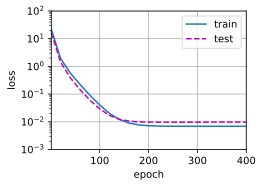

In [24]:
# 从多项式特征中选择前4个维度，即1、x、x^2/2!和x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4], labels[:n_train], labels[n_train:])

weight: [[3.2356312 3.439885 ]]


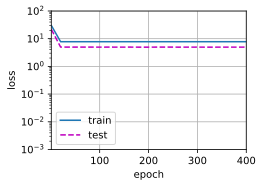

In [25]:
train(poly_features[:n_train, :2], poly_features[n_train:, :2], labels[:n_train], labels[n_train:])

weight: [[ 4.9316545   1.3476086  -3.153156    4.8868737  -0.51378375  1.8048898
  -0.03671349  0.22990096  0.07073364  0.1344048  -0.09200256 -0.15504266
   0.12021156  0.00977513  0.1295887   0.20933841 -0.19201481  0.09171941
  -0.10929152 -0.16441497]]


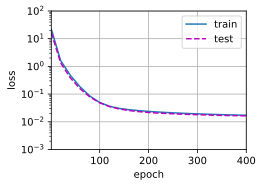

In [26]:
train(poly_features[:n_train, :], poly_features[n_train:, :], labels[:n_train], labels[n_train:])